## HMM Model to infer the distribution of the read depth of a sample and its potential contaminant

The model is a Hidden Markov Model whose states are clean depths range and whose generators (hidden states) are the drop out states: no drop out, drop out of the reference genome, drop out of the contaminant genome, or drop out of both genomes.
The model is trained on the read depth of a sample and its potential contaminant.

In [ ]:
%load_ext autoreload
%autoreload 2

from hmm.HMM import Cont_Detec_HMM
from hmmlearn.hmm import MultinomialHMM, GaussianHMM, CategoricalHMM
from statistics import median
import numpy as np
from pathlib import Path
import lzma
import gzip
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def generate_batchs_pairs(n_batchs):
    """Generate a 2D list with structure such that L[i][j] = sample j of batch i.
    Samples are pairs (path, read_name) where path is the path to the qc file.

    Args:
        n_batchs (int): Number of batches to generate.
    """
    path_vdn = "/nfs/research/zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Final_archiving/run2viridian_dir.tsv.xz"
    # Generate a list of ids to chose samples
    batchs_samples_list = [[] for _ in range(n_batchs)]

    with lzma.open(path_vdn, "rt") as f:
        # Each line is composed of read_name and path to qc file
        # Iterate over the lines and get the path, read_name if the line's index is in chosen_samples
        for i, line in enumerate(f):
            if i == 0:
                continue
            # Get the read_name and path
            read_name, path = line.strip().split("\t")
            path = path + "/qc.tsv.gz"
            batchs_samples_list[i % n_batchs].append((path, read_name))
            
            
        # for i, batch in tqdm(enumerate(batchs_samples_list), desc="Generating batches", total=n_batchs):
        #     with lzma.open(f"{data_storing_dir}/batches/batch_{i}.pkl.xz", "wb") as f:
        #         pickle.dump(batch, f)
        # Not enough memory to store all batches
    
    return batchs_samples_list

In [3]:
def get_category(median_depth, depth):
    """
    Categorical depth values.
    Categories ranges get larger exponentially.
    With median depth = 1000, the categories are:
    0: 0 - 5
    1: 5 - 20
    2: 20 - 50
    3: 50 - 100
    4: 100 - 300
    5: 300+
    """
    if depth < 0.005 * median_depth:
        return 0
    elif depth < 0.02* median_depth:
        return 1
    elif depth < 0.05 * median_depth:
        return 2
    elif depth < 0.1 * median_depth:
        return 3
    elif depth < 0.3 * median_depth:
        return 4
    else:
        return 5
    

In [75]:
# Only do it if sample_list does not already exist

try:
    sample_list
    
except:

    batchs_samples_list = generate_batchs_pairs(15000)

    sample_list = batchs_samples_list[0]

    del batchs_samples_list


In [85]:
def compute_dropout_lengths(dropout_list):
    lengths = []
    count = 0
    for state in dropout_list:
        if state:
            count += 1
        elif count > 0:
            lengths.append(count)
            count = 0
    if count > 0:  # Handle case where list ends with True
        lengths.append(count)
    return lengths

In [97]:

# Extract example data from a sample
depth_samples_cat_list = []
depth_samples_cont_list = []
amplicons_length_list = []
dropout_length_list = []
for path, read_name in tqdm(sample_list):
    clean_depth_list = []
    cons_depth_list = []
    amplicons_dict = {}
    dropout = False
    dropout_states = []

    # Read the data
    with gzip.open(path, "rb") as f:
        # Read the lines and create the needed values to apply the thresholds
        # List of all the clean_depth, list of het_prop, median_depth
        
        # b'Ref_pos\tRef_nt\tCons_pos\tCons_nt\tMasked_cons_nt\tAmplicon\tPrimer\tMask\tTotal_depth\tClean_depth\tCons_depth\tA\ta\tC\tc\tG\tg\tT\tt\tI\ti\tD\td\tX_A\tX_a\tX_C\tX_c\tX_G\tX_g\tX_T\tX_t\tX_I\tX_i\tX_D\tX_d\n'
        
        # Iterate over the lines in the file
        for line in f:
            # ignore header line
            if line.startswith(b"Ref_pos"):
                continue
            # Decode the line and split it into columns
            line = line.decode("utf-8").strip().split("\t")
            amplicons = line[5]
            mask = line[7]
            
            # Extract the values from the columns
            if mask == ".":
                # Skip the first and last lines where depths col are filled with .
                clean_depth = 0
                cons_depth = 0
            else:
                # Extract the values from the columns
                clean_depth = min(1000, int(line[9]))
                cons_depth = min(1000, int(line[10]))
                
                if clean_depth <= 20:
                    if not dropout:
                        dropout = True
                elif clean_depth > 50:
                    dropout = False
                    
                
                for amplicon in amplicons.split(";"):
                    if amplicon not in amplicons_dict:
                        amplicons_dict[amplicon] = 1
                    else:
                        amplicons_dict[amplicon] += 1
                        
            
            dropout_states.append(dropout)
            clean_depth_list.append(clean_depth)
            cons_depth_list.append(cons_depth)
    
    # Get the median of the clean_depth
    if len(clean_depth_list) == 29903:
        median_clean_depth = median(clean_depth_list)
        if median_clean_depth > 100:
            cat_cdlist = [get_category(median_clean_depth, depth) for depth in clean_depth_list]
            depth_samples_cat_list.append(cat_cdlist)
            depth_samples_cont_list.append(clean_depth_list)
            amplicon_average_length = sum(amplicons_dict.values()) / len(amplicons_dict)
            if amplicon_average_length > 500:
                test_amplicon_dict = amplicons_dict.copy()
            amplicons_length_list.append(amplicon_average_length)
            # Retrieve the dropout lengths as the sequences of true in dropout_states
            dropout_lengths_sample = compute_dropout_lengths(dropout_states)
            if len(dropout_lengths_sample) > 2:
                # Remove the first and last elements as they are not part of the dropout
                dropout_lengths_sample = dropout_lengths_sample[1:-1]
                dropout_length_list.append((dropout_lengths_sample, read_name))                
        
    

100%|██████████| 198/198 [00:16<00:00, 11.75it/s]


In [98]:
dropout_length_list

[([152, 260, 174, 189], 'ERR10213967'),
 ([288, 242, 14, 282], 'ERR4305804'),
 ([13, 278, 257, 285, 183, 255, 278, 278, 279], 'ERR5066031'),
 ([240], 'ERR5180279'),
 ([137], 'ERR5549957'),
 ([545], 'ERR5693239'),
 ([285], 'ERR5776883'),
 ([28, 282, 288, 95, 34, 469, 273, 285, 264, 430, 282], 'ERR5939416'),
 ([227], 'ERR6008073'),
 ([215], 'ERR6108100'),
 ([25, 264], 'ERR6207998'),
 ([274], 'ERR6308079'),
 ([282, 240, 297, 61, 257, 285, 258, 258, 295, 114, 267, 243, 297],
  'ERR6341229'),
 ([258], 'ERR6387413'),
 ([258, 70], 'ERR6426645'),
 ([221, 261], 'ERR6493830'),
 ([63, 293, 248, 246, 281, 143, 289, 345, 240, 284, 40, 277, 81],
  'ERR6571349'),
 ([163], 'ERR6704905'),
 ([285, 500], 'ERR6762775'),
 ([429], 'ERR6789585'),
 ([3], 'ERR6825463'),
 ([274], 'ERR6929841'),
 ([267, 295], 'ERR7093502'),
 ([274], 'ERR7158663'),
 ([297, 295, 274], 'ERR7199187'),
 ([250, 271, 242, 92, 108, 282, 261, 264, 240], 'ERR7240473'),
 ([205], 'ERR7306380'),
 ([174, 270], 'ERR7331663'),
 ([225], 'ERR7372

In [70]:
np.mean(amplicons_length_list), np.std(amplicons_length_list), len(amplicons_length_list)

(414.5294319402183, 108.59430150992148, 154)

In [28]:
X_depth_samples_cat = np.array(depth_samples_cat_list)
X_depth_samples_cont = np.array(depth_samples_cont_list)

n_samples, seq_length = X_depth_samples_cat.shape

X_depth_samples_cat = X_depth_samples_cat.reshape(-1, 1)
X_depth_samples_cont = X_depth_samples_cont.reshape(-1, 1)

lengths = [seq_length] * n_samples
lengths = np.array(lengths)

X_depth_samples_cat.shape, X_depth_samples_cont.shape, lengths.shape

((4605062, 1), (4605062, 1), (154,))

In [64]:
hmm_model = Cont_Detec_HMM(n_models=1, cont_prop=[0, 0.2])

X_scratch = X_depth_samples_cat.reshape(n_samples, seq_length)

In [65]:
hmm_model.initialize_params(X_scratch)


In [66]:
hmm_model.pi

array([0.14015427, 0.13148937, 0.30367372, 0.        , 0.        ,
       0.42468264])

In [35]:
X_scratch.shape

(154, 29903)

In [40]:
hmm_model.train(X_scratch, verbose=True)

Training:   0%|          | 0/10 [00:00<?, ?it/s]<string>:10: RuntimeWarning: invalid value encountered in divide
<string>:12: RuntimeWarning: invalid value encountered in divide
<string>:12: RuntimeWarning: divide by zero encountered in divide
Training:   0%|          | 0/10 [04:28<?, ?it/s]


KeyboardInterrupt: 

In [29]:

alpha, scale = hmm_model.forward(X_scratch[0])

In [33]:
i = 1000

alpha[i], X_scratch[0, :i+1]

(array([8.84743922e-012, 0.00000000e+000, 1.78415767e-224, 0.00000000e+000,
        2.74363533e-224, 0.00000000e+000, 2.66456329e-001, 2.79054028e-001,
        4.54489644e-001, 0.00000000e+000]),
 array([5, 5, 5, ..., 5, 5, 5]))

In [1]:
hmm_model_cat_4= CategoricalHMM(n_components=4, verbose=True, n_iter=200, tol=100)
# hmm_model_cont = GaussianHMM(n_components=4, covariance_type="full")

# Fit the model
# hmm_model_cat_4.fit(X_depth_samples_cat, lengths=lengths)
# hmm_cat_4_scratch.baum_welch(X_depth_clustered[]

NameError: name 'CategoricalHMM' is not defined

In [155]:
hmm_model_cat_2= CategoricalHMM(n_components=2, verbose=True, n_iter=200, tol=10)

# Fit the model
# hmm_model_cat_2.fit(X_depth_samples_cat, lengths=lengths)
hmm_model_cat_2.fit(X_depth_clustered, lengths=lengths)

         1 -9490015.19832539             +nan
         2 -5990471.98743894 +3499543.21088645
         3 -5950141.49075416  +40330.49668478
         4 -5940320.89627153   +9820.59448263
         5 -5937836.81450576   +2484.08176577
         6 -5937208.60650804    +628.20799771
         7 -5937050.59912297    +158.00738507
         8 -5937011.01546101     +39.58366196
         9 -5937001.12071100      +9.89475001


CategoricalHMM(n_components=2, n_features=5, n_iter=200,
               random_state=RandomState(MT19937) at 0x7F89A5E62C40, tol=10,
               verbose=True)

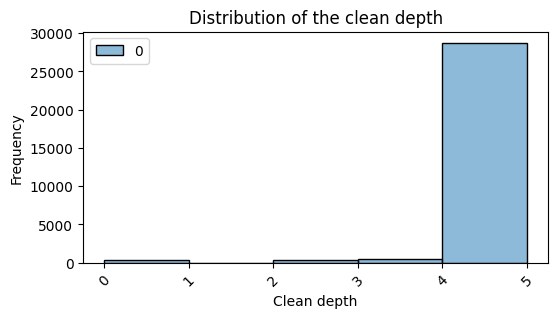

55


(120562.61326367053,
 113738.93677045766,
 120653.97611864726,
 113996.41390721027)

In [150]:
# Plot distribution of the data

i = np.random.randint(0, n_samples)

plt.figure(figsize=(6, 3))
plt.title("Distribution of the clean depth")
plt.xlabel("Clean depth")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
bins = [0, 1, 2, 3, 4, 5]
sample = X_depth_samples_cat[seq_length*i:seq_length*(i+1)]
sns.histplot(sample, bins=bins, color="blue", label="Clean depth")
plt.show()

print(i)

# Get the most likely hidden states
hidden_states_2 = hmm_model_cat_2.decode(sample, algorithm="viterbi")
hidden_states_4 = hmm_model_cat_4.decode(sample, algorithm="viterbi")
hid_seq_2 = hidden_states_2[1]
hid_seq_4 = hidden_states_4[1]
np.unique(sample, return_counts=True), np.unique(hid_seq_2, return_counts=True), np.unique(hid_seq_4, return_counts=True)


aic_2 = hmm_model_cat_2.aic(sample)
aic_4 = hmm_model_cat_4.aic(sample)
bic_2 = hmm_model_cat_2.bic(sample)
bic_4 = hmm_model_cat_4.bic(sample)

aic_2, aic_4, bic_2, bic_4

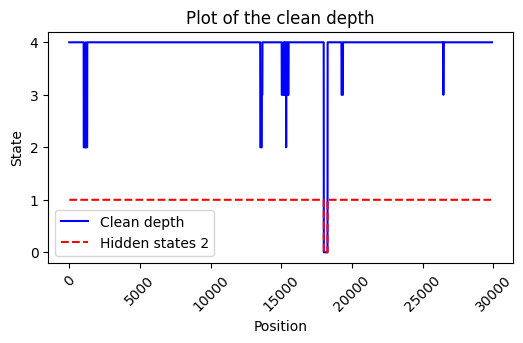

In [152]:
# Represent sample

plt.figure(figsize=(6, 3))
plt.title("Plot of the clean depth")
plt.xlabel("Position")
plt.ylabel("State")
plt.xticks(rotation=45)
plt.plot(sample, color="blue", label="Clean depth")
# Dash lines for the hidden states
plt.plot(hid_seq_2, color="red", label="Hidden states 2", linestyle="--")
# plt.plot(hid_seq_4, color="green", label="Hidden states 4", linestyle="--")
plt.legend()
plt.show()